# 03 ResNet50 Binary Classification

This notebook trains and evaluates a ResNet50 transfer learning model for binary image sentiment classification. The binary task compares positive sentiment against merged negative sentiment categories.

> **Note:** File paths are written for Google Colab. Update dataset/model paths before running in a new environment.

##1. Import libraries

In [ ]:
!pip install tensorflow

In [ ]:
!pip install -q split-folders

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

##2. Set dataset path and hyperparameters

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sargisiskandaryan/unsplash-images")

print("Path to dataset files:", path)

100%|██████████| 6.67G/6.67G [00:43<00:00, 163MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sargisiskandaryan/unsplash-images/versions/2


In [ ]:
# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset paths
input_folder = path
output_folder = "/content/sentiment_data_split"

# Image and training hyperparameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = 4

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10

INITIAL_LR = 1e-4
FINE_TUNE_LR = 1e-5

# Remove old split folder before re-splitting
if os.path.exists(output_folder):
    import shutil
    shutil.rmtree(output_folder)
    print(f"Removed old folder: {output_folder}")

##3. Split and Re-lable dataset

In [ ]:
# Check original class distribution
print("Original dataset distribution:")
for cls in os.listdir(input_folder):
    cls_path = os.path.join(input_folder, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))} images")
# Split dataset into train / val / test = 70 / 15 / 15
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=SEED,
    ratio=(0.7, 0.15, 0.15)
)
print("Data split completed.")

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

Original dataset distribution:
happy: 238 images
angry: 240 images
melancholic: 186 images
sad: 240 images


Copying files: 904 files [00:31, 28.26 files/s]

Data split completed.


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 632 files belonging to 4 classes.
Found 134 files belonging to 4 classes.
Found 138 files belonging to 4 classes.


In [ ]:
class_names = train_dataset.class_names
print("Class names:", class_names)

Class names: ['angry', 'happy', 'melancholic', 'sad']


In [ ]:
# Re-label the dataset into binary classification (Positive vs. Negative)
name_to_binary = {
    "angry": 0,
    "happy": 1,
    "melancholic": 0,
    "sad": 0
}

class_names_original = train_dataset.class_names

label_lookup = [name_to_binary[name] for name in class_names_original]

def map_to_binary(image, label):
    label = tf.cast(label, tf.int32)
    new_label = tf.gather(label_lookup, label)
    return image, new_label

In [ ]:
train_dataset = train_dataset.map(map_to_binary)
validation_dataset = validation_dataset.map(map_to_binary)
test_dataset = test_dataset.map(map_to_binary)

In [ ]:
class_names = ["negative", "positive"]

**Adjust Training Weights to Mitigate Class Imbalance**

In [ ]:
# Count samples in each binary class
negative_count = 0
positive_count = 0

for images, labels in train_dataset:
    negative_count += tf.reduce_sum(tf.cast(labels == 0, tf.int32)).numpy()
    positive_count += tf.reduce_sum(tf.cast(labels == 1, tf.int32)).numpy()

total = negative_count + positive_count

class_weight = {
    0: total / (2 * negative_count),
    1: total / (2 * positive_count)
}

print("Negative:", negative_count)
print("Positive:", positive_count)
print("Class weight:", class_weight)

Negative: 466
Positive: 166
Class weight: {0: np.float64(0.6781115879828327), 1: np.float64(1.9036144578313252)}


##4. Visualize samples

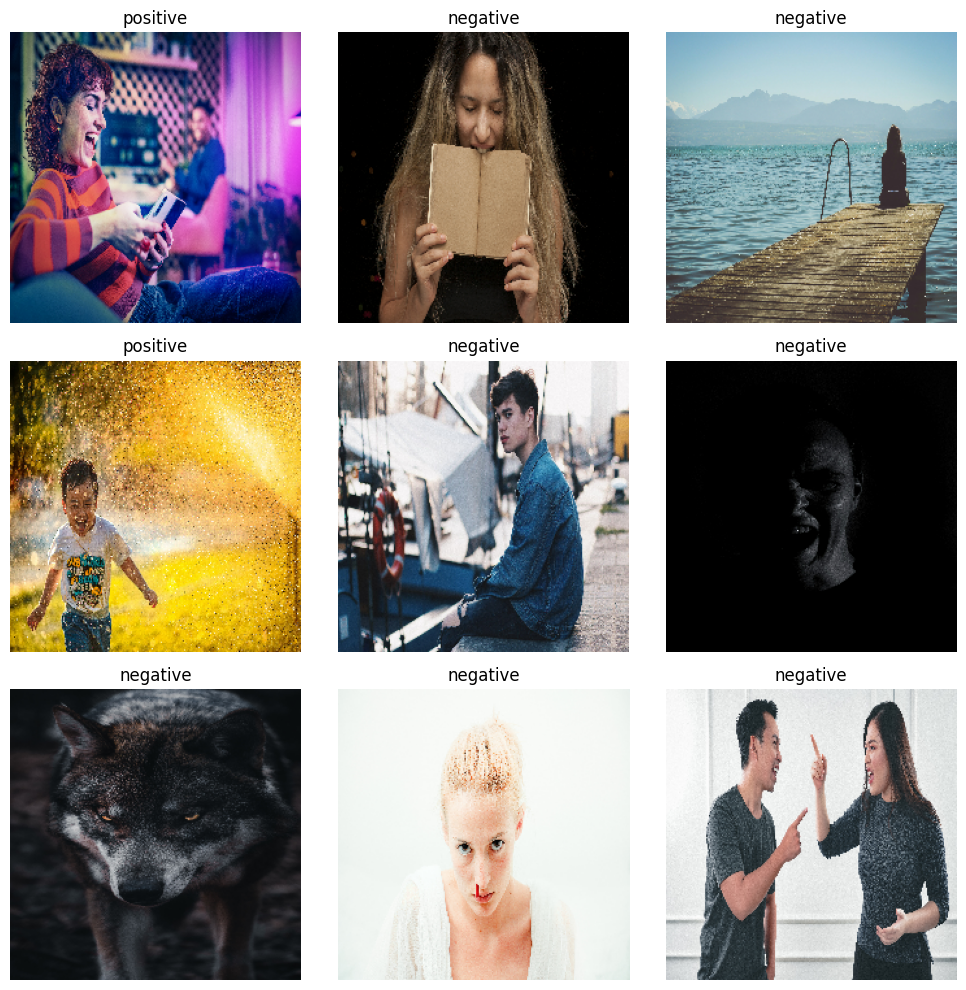

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

##5. Data preprocessing and data augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

##6. Load pretrained ResNet base model

In [ ]:
base_model = ResNet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False
print("Base model loaded. Trainable:", base_model.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded. Trainable: False


##7. Build the transfer learning model

In [ ]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      8,196 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

##8. Train the classifier head with frozen base

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.3560 - loss: 1.3783 - val_accuracy: 0.6343 - val_loss: 0.7717
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.5649 - loss: 0.9164 - val_accuracy: 0.7090 - val_loss: 0.6334
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.6187 - loss: 0.8413 - val_accuracy: 0.7537 - val_loss: 0.6104
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.6076 - loss: 0.7591 - val_accuracy: 0.7164 - val_loss: 0.5917
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.6361 - loss: 0.7238 - val_accuracy: 0.7910 - val_loss: 0.5408
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step - accuracy: 0.6994 - loss: 0.6603 - val_accuracy: 0.7687 - val_loss: 0.5399
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.6693 - loss: 0.6462 - val_accuracy: 0.7761 - val_loss: 0.5117
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.6835 - loss: 0.6537 - val_accuracy: 0.7612 - val_loss

##9. Fine-tune upper layers of ResNet


In [ ]:
base_model.trainable = True

In [ ]:
# Freeze lower layers, unfreeze upper layers
fine_tune_at = 140

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

total_epochs = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    validation_data=validation_dataset
)

Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step - accuracy: 0.6883 - loss: 0.5762 - val_accuracy: 0.7910 - val_loss: 0.4458
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 108s 5s/step - accuracy: 0.7848 - loss: 0.4710 - val_accuracy: 0.8060 - val_loss: 0.4588
Epoch 13/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.8212 - loss: 0.4031 - val_accuracy: 0.8284 - val_loss: 0.4390
Epoch 14/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.8370 - loss: 0.3703 - val_accuracy: 0.8358 - val_loss: 0.4178
Epoch 15/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.8766 - loss: 0.3205 - val_accuracy: 0.8507 - val_loss: 0.4058
Epoch 16/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.8576 - loss: 0.3164 - val_accuracy: 0.8582 - val_loss: 0.3902
Epoch 17/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 97s 5s/step - accuracy: 0.8718 - loss: 0.3156 - val_accuracy: 0.8433 - val_loss: 0.3973
Epoch 18/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - accuracy: 0.8908 - loss: 0.2797 - val_accuracy: 0.8657

**Plot training curves**

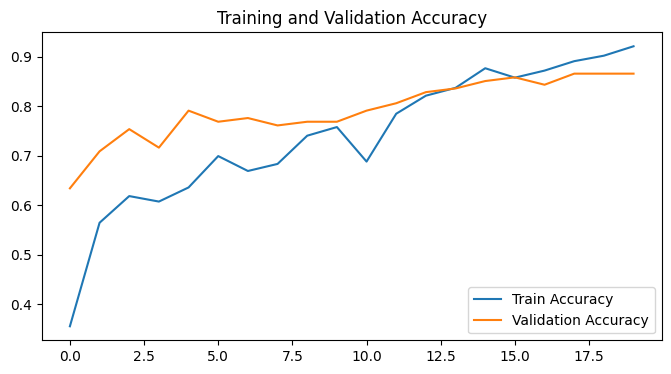

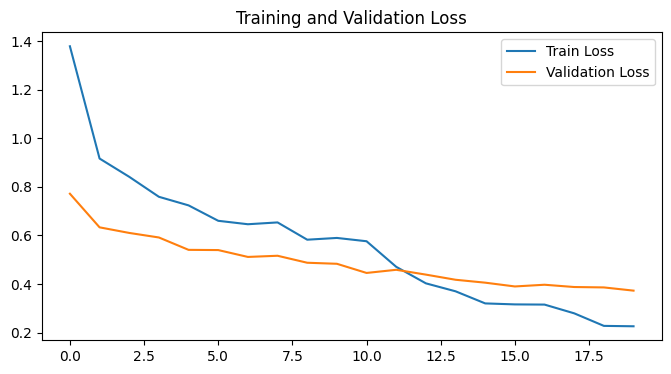

In [ ]:
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(8, 4))
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

##10. Evaluate the model

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8551 - loss: 0.3265
Test Loss: 0.32654595375061035
Test Accuracy: 0.8550724387168884


In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    negative       0.86      0.95      0.91       101
    positive       0.81      0.59      0.69        37

    accuracy                           0.86       138
   macro avg       0.84      0.77      0.80       138
weighted avg       0.85      0.86      0.85       138



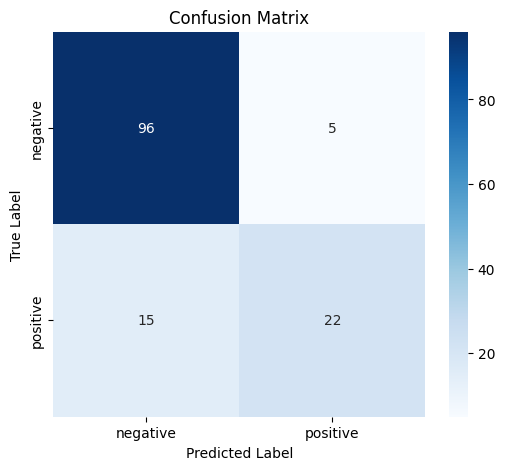

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("/content/resnet50_binary_class_model.keras")
print("Model saved successfully.")

Model saved successfully.


##11. Predict on new images

In [ ]:
def predict_single_image(image_path, model, class_names):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    pred_index = np.argmax(predictions[0])
    pred_class = class_names[pred_index]
    confidence = float(np.max(predictions[0]))

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}\nConfidence: {confidence:.4f}")
    plt.axis("off")
    plt.show()

    return pred_class, confidence

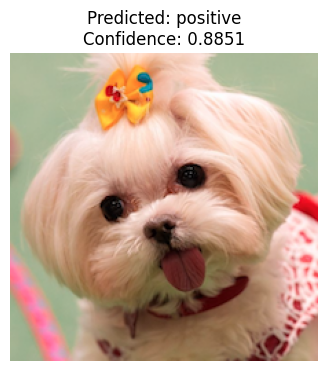

('positive', 0.8851471543312073)

In [ ]:
# Example
sample_image_path = "/content/ABC 6.png"
predict_single_image(sample_image_path, model, class_names)